# PyTorch로 딥러닝 최적화 함수 비교 실습

이 노트북은 같은 데이터셋과 같은 신경망 구조를 사용하여 여러 최적화 함수의 학습 결과를 비교한다.

비교할 최적화 함수는 다음과 같다.

- SGD
- SGD + Momentum
- RMSprop
- Adam
- AdamW

실습 목표는 최적화 함수가 바뀌면 손실값과 정확도 변화가 어떻게 달라지는지 확인하는 것이다.


## 1. 라이브러리 불러오기

PyTorch로 모델을 만들고, scikit-learn으로 간단한 분류 데이터셋을 생성한다.


In [1]:
# torch는 PyTorch의 핵심 라이브러리로, 텐서 연산과 딥러닝 모델 학습에 사용한다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 만들 때 사용하는 모듈이다.
import torch.nn as nn

# torch.optim은 SGD, Adam, AdamW 같은 최적화 함수를 제공하는 모듈이다.
import torch.optim as optim

# TensorDataset은 입력 데이터와 정답 데이터를 하나의 데이터셋 객체로 묶기 위해 사용한다.
from torch.utils.data import TensorDataset

# DataLoader는 데이터를 미니배치 단위로 나누어 모델에 공급하기 위해 사용한다.
from torch.utils.data import DataLoader

# make_moons는 두 개의 초승달 모양 클래스를 가진 비선형 분류 데이터셋을 생성한다.
from sklearn.datasets import make_moons

# train_test_split은 데이터를 학습용 데이터와 테스트용 데이터로 나누기 위해 사용한다.
from sklearn.model_selection import train_test_split

# StandardScaler는 입력 특성의 평균을 0, 표준편차를 1에 가깝게 표준화하기 위해 사용한다.
from sklearn.preprocessing import StandardScaler

# accuracy_score는 모델의 예측 정확도를 계산하기 위해 사용한다.
from sklearn.metrics import accuracy_score

# numpy는 배열 계산과 결과 저장을 위해 사용한다.
import numpy as np

# pandas는 최적화 함수별 결과를 표 형태로 정리하기 위해 사용한다.
import pandas as pd

# matplotlib.pyplot은 손실값과 정확도 그래프를 그리기 위해 사용한다.
import matplotlib.pyplot as plt

# random은 파이썬 기본 난수 생성을 고정하기 위해 사용한다.
import random


## 2. 실행 결과를 일정하게 만들기 위한 난수 고정

딥러닝은 가중치 초기화와 데이터 섞기 과정에서 난수가 사용된다.  
매번 결과가 크게 달라지지 않도록 seed 값을 고정한다.


In [2]:
# seed는 난수 생성 결과를 고정하기 위한 기준 숫자이다.
seed = 42

# 파이썬 random 모듈의 난수 생성 기준을 고정한다.
random.seed(seed)

# numpy의 난수 생성 기준을 고정한다.
np.random.seed(seed)

# PyTorch CPU 연산의 난수 생성 기준을 고정한다.
torch.manual_seed(seed)

# CUDA GPU를 사용할 수 있는 경우 GPU 연산의 난수 생성 기준도 고정한다.
torch.cuda.manual_seed_all(seed)

# 현재 실행 환경에서 GPU를 사용할 수 있으면 cuda를, 사용할 수 없으면 cpu를 사용하도록 장치를 설정한다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 실제로 사용할 연산 장치를 출력한다.
print("사용 장치:", device)


사용 장치: cpu


## 3. 데이터셋 생성 및 전처리

최적화 함수 차이를 확인하기 위해 직선 하나로는 쉽게 나눌 수 없는 `make_moons` 데이터셋을 사용한다.


In [3]:
# make_moons 함수로 샘플 2000개짜리 이진 분류 데이터셋을 생성한다.
X, y = make_moons(n_samples=2000, noise=0.25, random_state=seed)

# train_test_split으로 전체 데이터를 학습용 80%, 테스트용 20%로 나눈다.
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # 입력 데이터 전체를 전달한다.
    y,                  # 정답 라벨 전체를 전달한다.
    test_size=0.2,      # 전체 데이터 중 20%를 테스트 데이터로 사용한다.
    random_state=seed,  # 데이터를 나누는 난수 기준을 고정한다.
    stratify=y          # 클래스 비율이 학습/테스트 데이터에서 비슷하게 유지되도록 한다.
)

# StandardScaler 객체를 생성하여 입력 데이터의 스케일을 맞출 준비를 한다.
scaler = StandardScaler()

# 학습 데이터 기준으로 평균과 표준편차를 계산하고, 학습 데이터를 표준화한다.
X_train = scaler.fit_transform(X_train)

# 테스트 데이터는 학습 데이터에서 계산된 평균과 표준편차를 그대로 사용하여 표준화한다.
X_test = scaler.transform(X_test)

# numpy 배열인 학습 입력 데이터를 PyTorch float32 텐서로 변환한다.
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

# numpy 배열인 테스트 입력 데이터를 PyTorch float32 텐서로 변환한다.
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# numpy 배열인 학습 정답 데이터를 PyTorch long 텐서로 변환한다.
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

# numpy 배열인 테스트 정답 데이터를 PyTorch long 텐서로 변환한다.
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 학습 입력 텐서와 정답 텐서를 하나의 TensorDataset으로 묶는다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader를 사용하여 학습 데이터를 32개씩 미니배치로 가져오도록 설정한다.
train_loader = DataLoader(
    train_dataset,      # 미니배치로 나눌 학습 데이터셋을 전달한다.
    batch_size=32,      # 한 번의 학습 단계에서 사용할 데이터 개수를 32개로 설정한다.
    shuffle=True        # 매 epoch마다 데이터 순서를 섞어 학습 안정성을 높인다.
)

# 입력 데이터의 모양을 출력하여 특성 수가 2개인지 확인한다.
print("X_train shape:", X_train.shape)

# 정답 데이터의 클래스 종류를 출력하여 이진 분류 문제인지 확인한다.
print("classes:", np.unique(y_train))


X_train shape: (1600, 2)
classes: [0 1]


## 4. MLP 모델 정의

동일한 모델 구조에서 최적화 함수만 바꾸어 비교한다.


In [4]:
# SimpleMLP 클래스는 nn.Module을 상속하여 PyTorch 신경망 모델을 정의한다.
class SimpleMLP(nn.Module):
    # __init__ 메서드는 모델에 필요한 계층을 생성하는 초기화 함수이다.
    def __init__(self):
        # 부모 클래스인 nn.Module의 초기화 기능을 실행한다.
        super().__init__()

        # self.network는 여러 계층을 순서대로 연결한 신경망이다.
        self.network = nn.Sequential(
            # 첫 번째 Linear 계층은 입력 특성 2개를 은닉 노드 16개로 변환한다.
            nn.Linear(2, 16),

            # ReLU는 음수는 0으로, 양수는 그대로 통과시켜 비선형성을 추가한다.
            nn.ReLU(),

            # 두 번째 Linear 계층은 은닉 노드 16개를 다시 은닉 노드 16개로 변환한다.
            nn.Linear(16, 16),

            # 두 번째 ReLU도 모델이 복잡한 곡선 형태의 분류 경계를 학습하게 도와준다.
            nn.ReLU(),

            # 마지막 Linear 계층은 은닉 노드 16개를 클래스 2개의 점수로 변환한다.
            nn.Linear(16, 2)
        )

    # forward 메서드는 입력 데이터가 모델 내부를 통과하는 순전파 과정을 정의한다.
    def forward(self, x):
        # 입력 x를 self.network에 통과시켜 클래스별 점수를 반환한다.
        return self.network(x)


## 5. Optimizer 생성 함수

같은 모델에 대해 최적화 함수만 바꿔 실험할 수 있도록 함수로 만든다.


In [5]:
# get_optimizer 함수는 optimizer_name에 따라 서로 다른 PyTorch 최적화 함수를 생성한다.
def get_optimizer(optimizer_name, model):
    # optimizer_name이 "SGD"이면 기본 SGD 최적화 함수를 사용한다.
    if optimizer_name == "SGD":
        # SGD는 가장 기본적인 경사하강법 계열 최적화 함수이다.
        return optim.SGD(model.parameters(), lr=0.01)

    # optimizer_name이 "SGD_Momentum"이면 Momentum이 추가된 SGD를 사용한다.
    elif optimizer_name == "SGD_Momentum":
        # momentum=0.9는 이전 업데이트 방향을 90% 정도 반영하겠다는 의미이다.
        return optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    # optimizer_name이 "RMSprop"이면 RMSprop 최적화 함수를 사용한다.
    elif optimizer_name == "RMSprop":
        # RMSprop은 파라미터별로 학습률을 조정하여 학습을 안정화한다.
        return optim.RMSprop(model.parameters(), lr=0.001)

    # optimizer_name이 "Adam"이면 Adam 최적화 함수를 사용한다.
    elif optimizer_name == "Adam":
        # Adam은 Momentum과 RMSprop의 아이디어를 결합한 대표적인 최적화 함수이다.
        return optim.Adam(model.parameters(), lr=0.001)

    # optimizer_name이 "AdamW"이면 AdamW 최적화 함수를 사용한다.
    elif optimizer_name == "AdamW":
        # AdamW는 Adam에 weight_decay를 더 올바른 방식으로 적용하여 과적합을 줄이는 데 도움을 준다.
        return optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

    # 위 조건에 없는 이름이 들어오면 오류를 발생시킨다.
    else:
        # 사용자가 잘못된 최적화 함수 이름을 넣었음을 알려준다.
        raise ValueError("지원하지 않는 optimizer_name입니다.")


## 6. 학습 함수 정의

하나의 최적화 함수에 대해 모델을 학습시키고, epoch별 손실값과 정확도를 저장한다.


In [6]:
# train_one_optimizer 함수는 하나의 최적화 함수로 모델을 학습하고 결과를 반환한다.
def train_one_optimizer(optimizer_name, epochs=50):
    # 매 실험마다 같은 초기 가중치에서 시작하도록 PyTorch seed를 다시 고정한다.
    torch.manual_seed(seed)

    # SimpleMLP 모델 객체를 생성한다.
    model = SimpleMLP()

    # 모델을 CPU 또는 GPU 장치로 이동시킨다.
    model = model.to(device)

    # 다중 클래스 분류용 손실 함수인 CrossEntropyLoss를 생성한다.
    criterion = nn.CrossEntropyLoss()

    # optimizer_name에 해당하는 최적화 함수를 생성한다.
    optimizer = get_optimizer(optimizer_name, model)

    # epoch별 평균 손실값을 저장할 리스트를 생성한다.
    loss_history = []

    # epoch별 테스트 정확도를 저장할 리스트를 생성한다.
    acc_history = []

    # 지정한 epoch 수만큼 학습을 반복한다.
    for epoch in range(epochs):
        # 모델을 학습 모드로 전환한다.
        model.train()

        # 현재 epoch의 손실값 합계를 저장할 변수를 0으로 초기화한다.
        total_loss = 0.0

        # DataLoader에서 미니배치 입력과 정답을 하나씩 꺼낸다.
        for batch_X, batch_y in train_loader:
            # 미니배치 입력 데이터를 연산 장치로 이동시킨다.
            batch_X = batch_X.to(device)

            # 미니배치 정답 데이터를 연산 장치로 이동시킨다.
            batch_y = batch_y.to(device)

            # 이전 미니배치에서 계산된 기울기를 0으로 초기화한다.
            optimizer.zero_grad()

            # 모델에 입력 데이터를 넣어 클래스별 예측 점수를 계산한다.
            outputs = model(batch_X)

            # 예측 점수와 실제 정답을 비교하여 손실값을 계산한다.
            loss = criterion(outputs, batch_y)

            # 손실값을 기준으로 각 파라미터의 기울기를 계산한다.
            loss.backward()

            # 계산된 기울기를 사용하여 모델의 가중치와 편향을 업데이트한다.
            optimizer.step()

            # 현재 미니배치 손실값에 데이터 개수를 곱해 epoch 전체 손실 합계에 더한다.
            total_loss += loss.item() * batch_X.size(0)

        # epoch 전체 평균 손실값을 계산한다.
        avg_loss = total_loss / len(train_dataset)

        # 모델을 평가 모드로 전환한다.
        model.eval()

        # 평가 과정에서는 기울기를 계산하지 않도록 설정하여 메모리 사용량을 줄인다.
        with torch.no_grad():
            # 테스트 입력 데이터를 연산 장치로 이동시킨다.
            test_inputs = X_test_tensor.to(device)

            # 테스트 데이터에 대한 클래스별 예측 점수를 계산한다.
            test_outputs = model(test_inputs)

            # 가장 점수가 높은 클래스 번호를 최종 예측값으로 선택한다.
            test_preds = torch.argmax(test_outputs, dim=1)

            # 예측 결과를 CPU로 옮긴 뒤 numpy 배열로 변환한다.
            test_preds_np = test_preds.cpu().numpy()

            # 실제 정답과 예측값을 비교하여 정확도를 계산한다.
            test_acc = accuracy_score(y_test, test_preds_np)

        # 현재 epoch의 평균 손실값을 리스트에 저장한다.
        loss_history.append(avg_loss)

        # 현재 epoch의 테스트 정확도를 리스트에 저장한다.
        acc_history.append(test_acc)

        # 10 epoch마다 현재 학습 상태를 출력한다.
        if (epoch + 1) % 10 == 0:
            # optimizer 이름, epoch 번호, 손실값, 정확도를 보기 좋게 출력한다.
            print(f"{optimizer_name:12s} | Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Test Acc: {test_acc:.4f}")

    # 학습이 끝난 뒤 손실 기록, 정확도 기록, 최종 모델을 반환한다.
    return loss_history, acc_history, model


## 7. 여러 최적화 함수 학습 실행

같은 데이터와 같은 모델 구조에서 최적화 함수만 바꾸어 학습한다.


In [7]:
# 비교할 최적화 함수 이름 목록을 만든다.
optimizer_names = ["SGD", "SGD_Momentum", "RMSprop", "Adam", "AdamW"]

# 각 최적화 함수별 학습 결과를 저장할 딕셔너리를 생성한다.
results = {}

# optimizer_names에 들어 있는 최적화 함수를 하나씩 반복한다.
for optimizer_name in optimizer_names:
    # 현재 어떤 최적화 함수를 학습하는지 출력한다.
    print("\n학습 시작:", optimizer_name)

    # 현재 최적화 함수로 모델을 학습하고 결과를 받는다.
    loss_history, acc_history, model = train_one_optimizer(optimizer_name, epochs=50)

    # 현재 최적화 함수의 손실 기록, 정확도 기록, 모델을 딕셔너리에 저장한다.
    results[optimizer_name] = {
        "loss": loss_history,
        "accuracy": acc_history,
        "model": model
    }



학습 시작: SGD
SGD          | Epoch  10/50 | Loss: 0.3377 | Test Acc: 0.8650
SGD          | Epoch  20/50 | Loss: 0.3131 | Test Acc: 0.8800
SGD          | Epoch  30/50 | Loss: 0.3068 | Test Acc: 0.8800
SGD          | Epoch  40/50 | Loss: 0.3004 | Test Acc: 0.8800
SGD          | Epoch  50/50 | Loss: 0.2924 | Test Acc: 0.8825

학습 시작: SGD_Momentum
SGD_Momentum | Epoch  10/50 | Loss: 0.2408 | Test Acc: 0.9075
SGD_Momentum | Epoch  20/50 | Loss: 0.1509 | Test Acc: 0.9200
SGD_Momentum | Epoch  30/50 | Loss: 0.1367 | Test Acc: 0.9300
SGD_Momentum | Epoch  40/50 | Loss: 0.1373 | Test Acc: 0.9250
SGD_Momentum | Epoch  50/50 | Loss: 0.1466 | Test Acc: 0.9275

학습 시작: RMSprop
RMSprop      | Epoch  10/50 | Loss: 0.2285 | Test Acc: 0.9075
RMSprop      | Epoch  20/50 | Loss: 0.1569 | Test Acc: 0.9200
RMSprop      | Epoch  30/50 | Loss: 0.1402 | Test Acc: 0.9250
RMSprop      | Epoch  40/50 | Loss: 0.1366 | Test Acc: 0.9250
RMSprop      | Epoch  50/50 | Loss: 0.1350 | Test Acc: 0.9275

학습 시작: Adam
Adam    

## 8. 최종 결과 표로 확인

최적화 함수별 마지막 손실값과 마지막 정확도를 비교한다.


In [8]:
# 결과 표에 들어갈 행 데이터를 저장할 빈 리스트를 만든다.
summary_rows = []

# results 딕셔너리에서 최적화 함수 이름과 결과를 하나씩 꺼낸다.
for optimizer_name, result in results.items():
    # 현재 최적화 함수의 최종 손실값과 최종 정확도를 하나의 딕셔너리로 정리한다.
    summary_rows.append({
        "Optimizer": optimizer_name,
        "Final Loss": result["loss"][-1],
        "Final Test Accuracy": result["accuracy"][-1]
    })

# 리스트 형태의 결과를 pandas DataFrame으로 변환한다.
summary_df = pd.DataFrame(summary_rows)

# 정확도가 높은 순서로 결과 표를 정렬한다.
summary_df = summary_df.sort_values(by="Final Test Accuracy", ascending=False)

# 정리된 결과 표를 출력한다.
summary_df


,Optimizer,Final Loss,Final Test Accuracy
1,SGD_Momentum,0.146551,0.9275
3,Adam,0.135741,0.9275
2,RMSprop,0.135043,0.9275
4,AdamW,0.135911,0.9275
0,SGD,0.292409,0.8825


## 9. 손실값 변화 그래프

손실값이 빠르게 낮아질수록 해당 최적화 함수가 이 실험에서 빠르게 학습했다는 의미로 볼 수 있다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


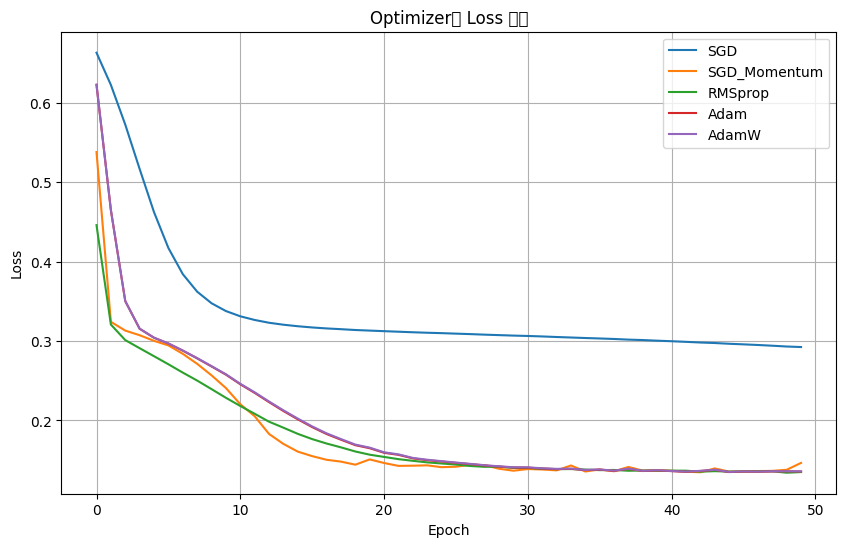

In [9]:
# 그래프 크기를 가로 10, 세로 6으로 설정한다.
plt.figure(figsize=(10, 6))

# 각 최적화 함수별 손실 기록을 그래프에 그린다.
for optimizer_name, result in results.items():
    # x축은 epoch, y축은 손실값이 되도록 선 그래프를 그린다.
    plt.plot(result["loss"], label=optimizer_name)

# 그래프 제목을 설정한다.
plt.title("Optimizer별 Loss 변화")

# x축 이름을 설정한다.
plt.xlabel("Epoch")

# y축 이름을 설정한다.
plt.ylabel("Loss")

# 각 선이 어떤 최적화 함수인지 보여주는 범례를 표시한다.
plt.legend()

# 그래프 격자선을 표시하여 값을 읽기 쉽게 만든다.
plt.grid(True)

# 그래프를 화면에 출력한다.
plt.show()


## 10. 정확도 변화 그래프

정확도가 빠르게 올라가고 안정적으로 유지되는 최적화 함수가 좋은 결과를 보인 것이다.


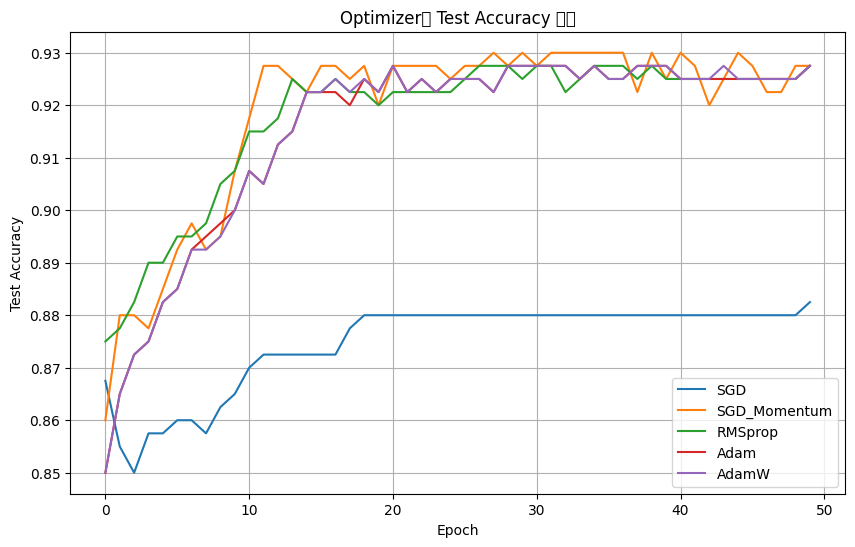

In [10]:
# 그래프 크기를 가로 10, 세로 6으로 설정한다.
plt.figure(figsize=(10, 6))

# 각 최적화 함수별 정확도 기록을 그래프에 그린다.
for optimizer_name, result in results.items():
    # x축은 epoch, y축은 테스트 정확도가 되도록 선 그래프를 그린다.
    plt.plot(result["accuracy"], label=optimizer_name)

# 그래프 제목을 설정한다.
plt.title("Optimizer별 Test Accuracy 변화")

# x축 이름을 설정한다.
plt.xlabel("Epoch")

# y축 이름을 설정한다.
plt.ylabel("Test Accuracy")

# 각 선이 어떤 최적화 함수인지 보여주는 범례를 표시한다.
plt.legend()

# 그래프 격자선을 표시하여 값을 읽기 쉽게 만든다.
plt.grid(True)

# 그래프를 화면에 출력한다.
plt.show()


## 11. 실습 해석

일반적으로 Adam과 AdamW는 초반 학습 속도가 빠르게 나타나는 경우가 많다.  
SGD는 단순하지만 학습률 설정에 민감하고, Momentum을 추가하면 더 안정적으로 이동할 수 있다.  
RMSprop은 파라미터별 학습률을 조정하므로 단순 SGD보다 안정적인 경우가 많다.

단, 어떤 최적화 함수가 항상 최고라는 뜻은 아니다.  
데이터셋, 모델 구조, 학습률, 배치 크기, epoch 수에 따라 결과는 달라질 수 있다.
